In [51]:
from difflib import SequenceMatcher
from tqdm import tqdm
import time
import pandas as pd
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
from spotipy.oauth2 import SpotifyOAuth
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import requests

### Authenticating with Spotify API

To authenticate with the Spotify API, we use Spotipy’s OAuth flow.  
Before doing this, we need two credentials from Spotify:

- Go to the **Spotify Developer Dashboard**: https://developer.spotify.com/dashboard
- Log in with your Spotify account.
- Click **"Create App"** (or open an existing app if you already have one).
- In the app page, copy your **Client ID**.
- Click **"Show Client Secret"** to reveal and copy your **Client Secret**.
- Add a **Redirect URI** in the app settings (e.g., `http://127.0.0.1:3000`) and save it.
- Use these values in Spotipy’s `SpotifyOAuth` to authenticate and access your playlists.


In [52]:
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(
    client_id="REMOVED_CLIENT_ID",
    client_secret="REMOVED_CLIENT_SECRET",
    redirect_uri="http://127.0.0.1:3000",
    
    scope="playlist-read-private playlist-read-collaborative"
))

print("Authenticated successfully!")


Authenticated successfully!


### Fetching User Profile
- Request the authenticated user's profile data from Spotify.
- Extract the user's **display name** from the response.
- Print the name to confirm the login was successful.


In [53]:
user = sp.current_user()
print("Logged in as:", user['display_name'])

Logged in as: Aakash Aadhithya


### Loading and Preparing the Dataset
- Load the Spotify dataset from the CSV file into a Pandas DataFrame.
- Count how many songs were released each year and sort the counts by year.
- Filter the dataset to keep only songs released **after 2012**.
- For each year:
  - Sort songs by **popularity** in descending order.
  - Select the **top 500 most popular songs**.
- Combine the yearly results into a final cleaned DataFrame.


In [54]:
df = pd.read_csv('spotify_data.csv')

In [55]:
Num_songs_by_year = df['year'].value_counts().sort_index()
Num_songs_by_year

year
2000    44034
2001    42351
2002    42102
2003    42368
2004    43390
2005    43780
2006    45474
2007    46001
2008    47432
2009    46869
2010    46868
2011    46444
2012    54797
2013    53216
2014    53179
2015    51607
2016    40273
2017    56241
2018    56572
2019    55793
2020    55066
2021    53566
2022    53692
2023    38649
Name: count, dtype: int64

In [56]:
df_filtered = df[df['year']> 2012].copy()

In [57]:
top_500_per_year = (
    df_filtered
    .sort_values(['year', 'popularity'], ascending=[True, False])
    .groupby('year')
    .head(500)
    .reset_index(drop=True)
)

### Fetching Artist Information in Batch
- Extract all unique artist names from the dataset.
- For each artist:
  - Search Spotify for matching artist profiles.
  - Compute similarity between returned names and the target name.
  - Select the best match and fetch:
    - Follower count  
    - Artist popularity  
    - Artist image URL
- Handle issues safely using:
  - Automatic token refresh
  - Rate-limit waiting (429 handling)
  - Retry attempts for connection errors
  - Catch-all fallback for unexpected errors
- Save partial progress every **200 artists** to avoid data loss.
- Return the final artist information as a DataFrame and save it to CSV.


In [58]:
def fetch_artist_info_batch(df, threshold=0.85, backup_path="artist_partial_backup.csv"):
    """
    Fetches followers, popularity, and image URL for unique artist names.
    Robust version with:
      - Auto token refresh
      - Rate-limit handling
      - Connection retries
      - Auto-save every 200 artists
      - Safe interrupt recovery
    """

    artist_names = df['artist_name'].dropna().unique().tolist()
    artist_info = {}

    print(f"Fetching info for {len(artist_names)} unique artists...")

    try:
        for i, artist_name in enumerate(tqdm(artist_names, desc="Fetching artist info")):
            success = False
            retry_count = 0

            while not success and retry_count < 5:
                try:
                    # --- API call
                    results = sp.search(q=artist_name, type="artist", limit=10)
                    artists = results['artists']['items']

                    # --- Find the best match
                    matched = False
                    for artist in artists:
                        name = artist['name']
                        sim = SequenceMatcher(None, name.lower(), artist_name.lower()).ratio()
                        if sim >= threshold:
                            followers = artist['followers']['total']
                            popularity = artist['popularity']
                            image_url = artist['images'][0]['url'] if artist['images'] else None
                            artist_info[artist_name] = (followers, popularity, image_url)
                            matched = True
                            break

                    if not matched:
                        artist_info[artist_name] = (None, None, None)

                    success = True  # success for this artist

                # --- Handle Spotify API errors
                except spotipy.exceptions.SpotifyException as e:
                    # Token expired
                    if e.http_status == 401:
                        print("Token expired — refreshing...")
                        sp.auth_manager.get_access_token(as_dict=False)
                        time.sleep(2)
                    # Rate limit
                    elif e.http_status == 429:
                        retry_after = int(e.headers.get('Retry-After', 30))
                        print(f"Rate limit hit — sleeping {retry_after} seconds...")
                        time.sleep(retry_after + 2)
                    else:
                        print(f"Spotify API error for {artist_name}: {e}")
                        artist_info[artist_name] = (None, None, None)
                        success = True

                # --- Handle connection errors
                except requests.exceptions.ConnectionError:
                    print(f"Connection error for {artist_name}. Retrying in 10s...")
                    time.sleep(10)
                    retry_count += 1

                # --- Catch-all for unexpected errors
                except Exception as e:
                    print(f"Other error for {artist_name}: {e}")
                    artist_info[artist_name] = (None, None, None)
                    success = True

                time.sleep(0.15)  # polite delay to avoid rate limit

            # --- Auto-save every 200 artists
            if (i + 1) % 200 == 0:
                print(f"Saving partial progress at {i+1} artists...")
                temp_df = (
                    pd.DataFrame.from_dict(
                        artist_info, orient='index',
                        columns=['followers', 'popularity_artist_2025', 'image_url_artist']
                    )
                    .reset_index()
                    .rename(columns={'index': 'artist_name'})
                )
                temp_df.to_csv(backup_path, index=False)

    except KeyboardInterrupt:
        print("\nInterrupted manually — returning fetched results so far...")

    # --- Final conversion to DataFrame
    artist_df = (
        pd.DataFrame.from_dict(
            artist_info, orient='index',
            columns=['followers', 'popularity_artist_2025', 'image_url_artist']
        )
        .reset_index()
        .rename(columns={'index': 'artist_name'})
    )

    artist_df.to_csv(backup_path, index=False)
    print(f"Done! Saved {len(artist_df)} records to {backup_path}")
    return artist_df

### Fetching Song Information in Batch
- Extract all unique track IDs from the dataset.
- For each track ID:
  - Call Spotify API to fetch:
    - Whether the track is **explicit**
    - Track **popularity**
    - Album **cover image URL**
- Handle issues automatically:
  - Refresh OAuth token on 401 errors
  - Wait and retry on rate-limit errors (429)
  - Retry failed connections up to 5 times
  - Safely catch all unexpected errors
- Save partial progress every **300 tracks** to avoid losing results.
- Return the complete track information as a DataFrame and save it to CSV.


In [59]:
def fetch_song_info_batch(df, backup_path="song_partial_backup.csv"):
    """
    Fetches explicitness, popularity, and album image for unique track IDs.
    Fully robust version:
      - Handles rate limits, token refresh, and connection drops
      - Auto-saves every 300 tracks
      - Returns partial results if interrupted
    """

    track_ids = df['track_id'].dropna().unique().tolist()
    track_info = {}

    print(f"Fetching info for {len(track_ids)} unique tracks...")

    try:
        for i, track_id in enumerate(tqdm(track_ids, desc="Fetching song info")):
            success = False
            retry_count = 0

            while not success and retry_count < 5:
                try:
                    # --- main API call
                    track = sp.track(track_id)
                    explicit = track.get('explicit', None)
                    popularity = track.get('popularity', None)
                    album_images = track['album'].get('images', [])
                    image_url_song = album_images[0]['url'] if album_images else None
                    track_info[track_id] = (explicit, popularity, image_url_song)
                    success = True

                except spotipy.exceptions.SpotifyException as e:
                    # --- Token expired
                    if e.http_status == 401:
                        print("Token expired — refreshing...")
                        sp.auth_manager.get_access_token(as_dict=False)
                        time.sleep(2)

                    # --- Rate limit hit
                    elif e.http_status == 429:
                        retry_after = int(e.headers.get('Retry-After', 30))
                        print(f"Rate limit hit — sleeping {retry_after} seconds...")
                        time.sleep(retry_after + 2)

                    else:
                        print(f"Spotify error for {track_id}: {e}")
                        track_info[track_id] = (None, None, None)
                        success = True

                except requests.exceptions.ConnectionError:
                    print(f"Connection error for {track_id}. Retrying in 10s...")
                    time.sleep(10)
                    retry_count += 1

                except Exception as e:
                    print(f"Other error fetching {track_id}: {e}")
                    track_info[track_id] = (None, None, None)
                    success = True

                time.sleep(0.15)  # polite delay

            # --- Auto-save progress every 300 tracks
            if (i + 1) % 300 == 0:
                print(f"Saving partial progress at {i+1} tracks...")
                temp_df = (
                    pd.DataFrame.from_dict(
                        track_info, orient='index',
                        columns=['explicit', 'song_popularity_2025', 'image_url_song']
                    )
                    .reset_index()
                    .rename(columns={'index': 'track_id'})
                )
                temp_df.to_csv(backup_path, index=False)

    except KeyboardInterrupt:
        print("\nInterrupted manually — returning fetched results so far...")

    # --- Final conversion to DataFrame
    track_df = (
        pd.DataFrame.from_dict(
            track_info, orient='index',
            columns=['explicit', 'song_popularity_2025', 'image_url_song']
        )
        .reset_index()
        .rename(columns={'index': 'track_id'})
    )

    # --- Final save (optional)
    track_df.to_csv(backup_path, index=False)
    print(f"Done! Saved {len(track_df)} records to {backup_path}")
    return track_df


In [60]:
#artist_df = fetch_artist_info_batch(top_500_per_year)

In [61]:
#song_info = fetch_song_info_batch(top_500_per_year)

### Merging Artist and Song Information
- Merge the top-500-songs DataFrame with the artist information using **artist name**.
- Merge the result with the song-level information using **track name**.
- Use left joins to ensure all selected songs remain in the dataset even if some metadata is missing.


In [62]:
#top_500_per_year = top_500_per_year.merge(artist_df, on='artist_name', how='left')
#top_500_per_year = top_500_per_year.merge(song_info, on='track_name', how='left')

In [63]:
top_500_per_year = pd.read_csv('2013 to 2023 songs.csv')
top_500_per_year.drop(columns=['Unnamed: 0.1','Unnamed: 0'],inplace= True)

In [64]:
top_500_per_year

,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,...,valence,tempo,duration_ms,time_signature,explicit,song_popularity_2025,image_url_song,followers,popularity_artist_2025,image_url_artist
0,Arctic Monkeys,I Wanna Be Yours,5XeFesFbtLpXzIVDNQP22n,91,2013,garage,0.464,0.417,0,-9.345,...,0.4790,67.528,183956,4,False,91,https://i.scdn.co/image/ab67616d0000b2734ae1c4...,32116566.0,85.0,https://i.scdn.co/image/ab6761610000e5eb7da39d...
1,Arctic Monkeys,Do I Wanna Know?,5FVd6KXrgO9B3JPmC8OPst,86,2013,garage,0.548,0.532,5,-7.596,...,0.4050,85.030,272394,4,False,86,https://i.scdn.co/image/ab67616d0000b2734ae1c4...,32116566.0,85.0,https://i.scdn.co/image/ab6761610000e5eb7da39d...
2,Arctic Monkeys,Why'd You Only Call Me When You're High?,086myS9r57YsLbJpU0TgK9,85,2013,garage,0.691,0.631,2,-6.478,...,0.8000,92.004,161124,4,False,84,https://i.scdn.co/image/ab67616d0000b2734ae1c4...,32116566.0,85.0,https://i.scdn.co/image/ab6761610000e5eb7da39d...
3,Avicii,Wake Me Up,0nrRP2bk19rLc0orkWPQk2,84,2013,dance,0.532,0.783,2,-5.697,...,0.6430,124.080,247427,4,False,85,https://i.scdn.co/image/ab67616d0000b273e14f11...,23437935.0,79.0,https://i.scdn.co/image/ab6761610000e5ebae0717...
4,John Legend,All of Me,3U4isOIWM3VvDubwSI3y7a,83,2013,pop,0.422,0.264,8,-7.064,...,0.3310,119.930,269560,4,False,85,https://i.scdn.co/image/ab67616d0000b27394c921...,8086999.0,74.0,https://i.scdn.co/image/ab6761610000e5eb01784e...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,Skrillex,Leave Me Like This,6NRvZuFXn2ixp8YdzUvG5n,65,2023,edm,0.671,0.840,1,-8.199,...,0.2330,124.977,188571,4,False,52,https://i.scdn.co/image/ab67616d0000b2736382f0...,7527720.0,74.0,https://i.scdn.co/image/ab6761610000e5ebe32002...
5496,Skrillex,Tears,29tRu5BqKiUDAoWLKIO3RN,65,2023,edm,0.697,0.633,5,-5.288,...,0.3690,140.216,185571,4,False,50,https://i.scdn.co/image/ab67616d0000b2736382f0...,7527720.0,74.0,https://i.scdn.co/image/ab6761610000e5ebe32002...
5497,Skrillex,Supersonic (my existence),3qL63QvSTHvC4Uw8eEhz4z,65,2023,edm,0.555,0.676,9,-6.531,...,0.0649,85.889,165372,4,False,58,https://i.scdn.co/image/ab67616d0000b2736382f0...,7527720.0,74.0,https://i.scdn.co/image/ab6761610000e5ebe32002...
5498,VINAI,Ghost Town (Lucas Estrada Remix),0ndg56b510prqHlImqJoxG,65,2023,edm,0.720,0.930,8,-5.021,...,0.6340,125.038,137957,4,False,55,https://i.scdn.co/image/ab67616d0000b273e729e0...,506418.0,62.0,https://i.scdn.co/image/ab6761610000e5eb45febd...


###  Inspecting and Cleaning the Final Dataset
- Check how many unique values each column contains (data consistency check).
- Identify missing values in all columns to understand what needs cleaning.
- Prepare to clean and finalize the dataset now that all external metadata has been merged.


In [65]:
top_500_per_year.nunique()

artist_name               1825
track_name                5316
track_id                  5500
popularity                  40
year                        11
genre                       58
danceability               713
energy                     870
key                         12
loudness                  4103
mode                         2
speechiness               1096
acousticness              2052
instrumentalness          1930
liveness                  1073
valence                   1032
tempo                     4882
duration_ms               5095
time_signature               5
explicit                     2
song_popularity_2025        91
image_url_song            3691
followers                 1817
popularity_artist_2025      73
image_url_artist          1814
dtype: int64

In [66]:
top_500_per_year.isna().sum()

artist_name                0
track_name                 0
track_id                   0
popularity                 0
year                       0
genre                      0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
duration_ms                0
time_signature             0
explicit                   0
song_popularity_2025       0
image_url_song             1
followers                 18
popularity_artist_2025    18
image_url_artist          35
dtype: int64

### Cleaning Missing Artist & Song Metadata
- Inspect missing values in the merged dataset.
- Missing image URLs do not require complex imputation.
- Replace missing image URLs with a generic placeholder image:
- Handle missing numeric fields such as:
  - `followers`
  - `popularity_artist_2025`
- Fill these with suitable default values or leave as NaN based on modeling needs.


In [67]:
place_holder_for_song = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/ac/No_image_available.svg/512px-No_image_available.svg.png"

In [68]:
indx = top_500_per_year[top_500_per_year['image_url_song'].isna()].index
top_500_per_year.loc[indx,'image_url_song'] = place_holder_for_song

In [69]:
place_holder_for_artist = "https://upload.wikimedia.org/wikipedia/commons/8/89/Portrait_Placeholder.png"

In [70]:
temp = top_500_per_year['image_url_artist'].isna()
top_500_per_year.loc[temp,'image_url_artist'] = place_holder_for_artist

In [71]:
missing = top_500_per_year['image_url_artist'].isna()
top_500_per_year.loc[missing,'image_url_artist'] = place_holder_for_artist

### Missing Data Exploration & MCAR Testing

- Install the **missingno** library for visualizing missing data patterns.



In [72]:
!pip install missingno


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\aadhi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


- Create indicator columns to mark missing values:
  - `followers_missing` → 1 if followers is missing, else 0
  - `pop_missing` → 1 if artist popularity is missing, else 0

In [73]:
top_500_per_year['followers_missing'] = top_500_per_year['followers'].isna().astype(int)
top_500_per_year['pop_missing'] = top_500_per_year['popularity_artist_2025'].isna().astype(int)


- Define a custom implementation of **Little’s MCAR Test** to check whether the missing data mechanism is:
  - MCAR (Missing Completely At Random)
  - MAR (Missing At Random)
  - MNAR (Missing Not At Random)
- The test works by:
  - Considering only numeric columns
  - Computing missingness patterns
  - Comparing group-wise means with overall means
  - Calculating a chi-square statistic and corresponding p-value


In [74]:
from scipy.stats import chi2

def little_mcar_test(df):
    df = df.copy()
    df = df.select_dtypes(include=[np.number])  # only numeric columns allowed
    n, d = df.shape

    # means
    means = np.nanmean(df, axis=0)

    # overall covariance estimate
    S = np.nan_to_num(df - means).T @ np.nan_to_num(df - means) / n

    # missingness patterns
    patterns = df.isna().astype(int)
    unique_patterns = patterns.drop_duplicates()

    chi_square = 0
    df_deg = 0

    for _, pattern in unique_patterns.iterrows():
        idx = (patterns == pattern).all(axis=1)
        group = df[idx]

        # observed variables in this pattern
        obs = np.where(pattern == 0)[0]

        if len(obs) == 0:
            continue

        group_n = group.shape[0]
        group_mean = np.nanmean(group.iloc[:, obs], axis=0)

        diff = group_mean - means[obs]
        S_obs = S[np.ix_(obs, obs)]

        chi_square += group_n * (diff @ np.linalg.inv(S_obs) @ diff)
        df_deg += len(obs)

    p_value = 1 - chi2.cdf(chi_square, df_deg)

    return chi_square, df_deg, p_value


- Run the MCAR test on:
  - `followers`
  - `popularity_artist_2025`
- Print the chi-square value, degrees of freedom, and p-value to interpret whether missingness is random.

In [75]:
subset = top_500_per_year[['followers', 'popularity_artist_2025']]
chi, df_deg, p = little_mcar_test(subset)

print("Chi-square:", chi)
print("Degrees of freedom:", df_deg)
print("p-value:", p)


Chi-square: 0.0
Degrees of freedom: 2
p-value: 1.0


### Interpreting Little’s MCAR Test Results
- Review the chi-square statistic, degrees of freedom, and p-value.
- A **high p-value (close to 1.0)** indicates:
  - No significant difference between missingness patterns.
  - Missing data is likely **MCAR (Missing Completely At Random)**.
- MCAR means:
  - The missing values in `followers` and `popularity_artist_2025` are **not related** to any other variables.
  - Simple imputation (mean/median/zero/placeholder) will not bias the dataset.
- Since p-value = **1.0**, we can safely proceed with straightforward cleaning/imputation.


###  Analyzing the Distribution of Followers
- Examine the distribution of non-missing follower counts.
- Identify whether the data is symmetric, skewed, or contains outliers.
- Understanding the shape of the distribution helps in choosing the correct imputation method.
- Plot a histogram to visually inspect skewness and overall spread.


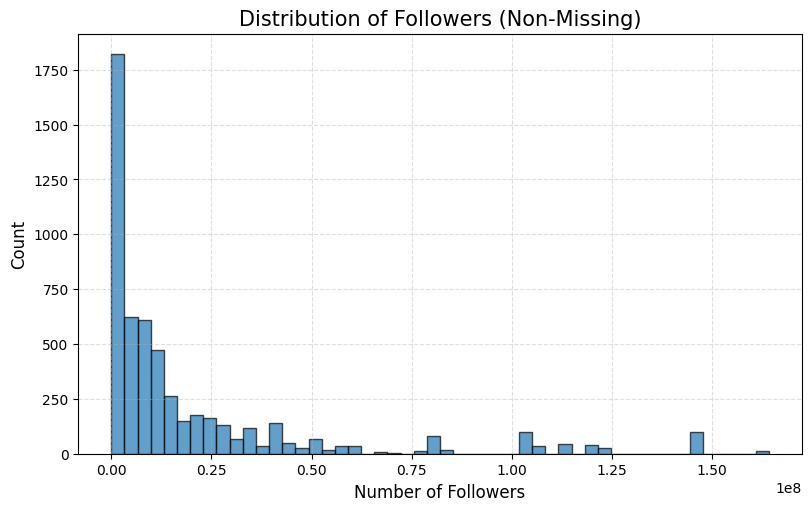

In [77]:
nans = top_500_per_year['followers'].isna()
x = top_500_per_year.loc[~nans, 'followers']

fig, ax = plt.subplots(figsize=(8,5), layout='constrained')

ax.hist(
    x,
    bins=50,                     
    edgecolor='black',          
    alpha=0.7                    
)

ax.set_title("Distribution of Followers (Non-Missing)", fontsize=15)
ax.set_xlabel("Number of Followers", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()


### Imputing Missing Follower Counts
- Plot inspection shows the follower distribution is **highly right-skewed**.
- Skewed numeric data is best imputed using the **median**, not mean or mode.
- Median is robust to extreme values (e.g., a few artists with millions of followers).
- Replace missing follower values with the median of the non-missing observations.


In [78]:
top_500_per_year.loc[nans,'followers'] = top_500_per_year['followers'].median()

### Analyzing Artist Popularity Distribution
- Examine the distribution of non-missing artist popularity scores.
- Check whether the popularity values are evenly spread or concentrated in certain ranges.
- Identify skewness or unusual patterns that may affect imputation or modeling.
- Plot a histogram to visually inspect the overall shape of the popularity data.


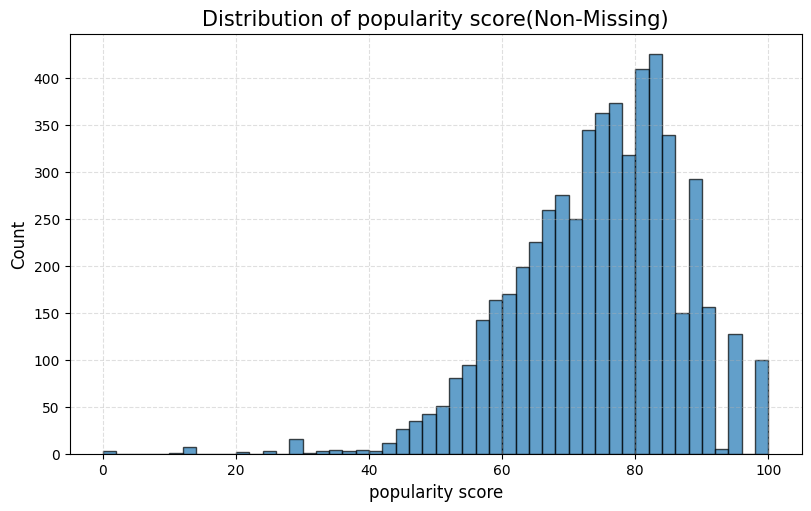

In [79]:
nans_2 = top_500_per_year['popularity_artist_2025'].isna()
x = top_500_per_year.loc[~nans_2, 'popularity_artist_2025']

fig, ax = plt.subplots(figsize=(8,5), layout='constrained')

ax.hist(
    x,
    bins=50,                  
    edgecolor='black',          
    alpha=0.7                     
)

ax.set_title("Distribution of popularity score(Non-Missing)", fontsize=15)
ax.set_xlabel("popularity score", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()


### Imputing Missing Artist Popularity Scores
- The histogram indicates that artist popularity values are slightly skewed.
- Median imputation is suitable for skewed numeric data because it is not affected by extreme values.
- Replace missing popularity scores with the median of the observed values.


In [80]:
top_500_per_year.loc[nans_2,'popularity_artist_2025'] = top_500_per_year['popularity_artist_2025'].median()

### Saving and Reloading the Cleaned Dataset
- Save the fully cleaned dataset to a CSV file for future use.
- Reload the file to confirm that all transformations have been applied correctly.
- Work on the reloaded version (`cleaned_data.csv`) to ensure a clean and consistent starting point.


In [85]:
top_500_per_year.to_csv('cleaned_data.csv')

In [86]:
data = pd.read_csv('cleaned_data.csv',index_col= 0)

### Preparing Artist-Level Data for Dashboard Cards
#### Goal
- Build a clean data storage system for a dashboard where **each artist will have an individual card**.
- Each card will later display:
  - Artist’s songs
  - Audio features
  - Popularity trends
  - Year-wise breakdown
#### What This Script Does
- Loads the cleaned master dataset (`cleaned_data.csv`).
- Sanitizes artist names to create safe filenames by:
  - Replacing spaces with underscores  
  - Removing invalid characters **using regular expressions (regex)**  
  - Ensuring every name becomes a clean, filesystem-safe identifier  
- Organizes the output into structured folders:
  - **All-Time Folder** → CSVs for the top 40 artists overall.
  - **Yearly Folders (2013–2023)** → CSVs for the top 20 artists of each year.
- Saves each artist’s data as a separate CSV file for modular dashboard loading.
- Automatically skips years with no data present.

#### Why This Structure Helps the Dashboard
- Each artist card can load a **small, isolated CSV** instead of parsing the whole dataset → faster UI.
- Cards can be generated dynamically based on filenames.
- Regex-sanitized file names ensure:
  - No broken paths
  - No invalid characters
  - Cross-platform compatibility (Windows/Linux/Mac)
- Supports both **global artist cards** and **year-specific panels**.



In [88]:
import os
import re
def sanitize_filename(name):
    """
    Sanitizes a string to be a safe filename.
    Replaces spaces with underscores and removes punctuation.
    """
    # Replace spaces with underscores
    name = name.replace(' ', '_')
    # Remove all punctuation except the underscore
    name = re.sub(r'[^\w_]', '', name)
    return name

# --- Main Script ---
print("Starting data preparation...")
try:
    df = data.copy()
except FileNotFoundError:
    print("Error: 'cleaned_data.csv' not found. Please make sure it's in the same directory.")
    exit()

# 1. Create 'all_time' folder with Top 40 artists
print("Processing all-time data...")
all_time_folder = "artists_csv/all_time"
os.makedirs(all_time_folder, exist_ok=True)

# Get value counts for all-time
df_artists_all = df["artist_name"].value_counts()

for artist_name in df_artists_all.index[:40]:
    safe_name = sanitize_filename(artist_name)
    file_path = os.path.join(all_time_folder, f"{safe_name}.csv")
    
    # Filter the main dataframe for this artist
    df_artist = df[df["artist_name"] == artist_name]
    df_artist.to_csv(file_path, index=False)

print(f"Created all_time data for top 40 artists in '{all_time_folder}'")

# 2. Create per-year folders (2013-2023) with Top 20 artists
print("Processing per-year data (2013-2023)...")
for i in range(2013, 2024):
    print(f"  Processing year: {i}")
    
    # --- FIX: Filter by the loop variable 'i', not hardcoded '2013'
    df_year = df[df["year"] == i]
    
    if df_year.empty:
        print(f"    No data found for {i}, skipping.")
        continue
        
    # --- FIX: Create a folder for the year
    year_folder = f"artists_csv/{i}"
    os.makedirs(year_folder, exist_ok=True)

    df_artists_year = df_year["artist_name"].value_counts()
    
    for artist_name in df_artists_year.index[:20]:
        safe_name = sanitize_filename(artist_name)
        file_path = os.path.join(year_folder, f"{safe_name}.csv")
        
        # --- FIX: Corrected the filtering syntax (== instead of =)
        df_artist = df_year[df_year["artist_name"] == artist_name]
        df_artist.to_csv(file_path, index=False)

print("Data preparation complete!")

Starting data preparation...
Processing all-time data...
Created all_time data for top 40 artists in 'artists_csv/all_time'
Processing per-year data (2013-2023)...
  Processing year: 2013
  Processing year: 2014
  Processing year: 2015
  Processing year: 2016
  Processing year: 2017
  Processing year: 2018
  Processing year: 2019
  Processing year: 2020
  Processing year: 2021
  Processing year: 2022
  Processing year: 2023
Data preparation complete!


###  Visualizing Top Genres Over Time (Animated Bar Chart)
- Identify how many unique genres exist in the cleaned dataset.


In [ ]:
data['genre'].nunique()

58

In [ ]:
data['genre'].value_counts()

genre
pop                  1102
hip-hop              1036
dance                 758
country               294
k-pop                 262
indie-pop             215
sad                   183
alt-rock              172
electro               149
emo                   118
folk                  100
rock                   97
french                 93
chill                  86
edm                    80
funk                   71
sertanejo              71
pop-film               64
metal                  61
house                  52
german                 40
ambient                39
singer-songwriter      38
indian                 35
show-tunes             29
jazz                   29
garage                 21
sleep                  18
acoustic               18
blues                  17
gospel                 13
soul                   13
swedish                12
piano                  12
spanish                12
forro                  11
punk                   11
classical              11
disco 

- Select the **top 10 most common genres** for clearer visualization.
- Filter the data to include only these top genres.
- Compute the number of songs per **genre × year** using a groupby.
- Create a complete grid of all (year, genre) combinations to:
  - Avoid flickering in the animation
  - Ensure every genre appears for every year (missing values become 0)
- Merge the real counts with the full grid and fill missing values with zero.
- Sort the data so each year’s bars appear in descending order.
- Build an animated horizontal bar chart using Plotly:
  - Each frame represents a year
  - Bars move smoothly as the count changes across years
- Apply stable colors for each genre to maintain consistency across frames.
- Adjust animation speed and transitions for a smoother playback experience.

In [ ]:
import plotly.express as px

In [ ]:
TOP_N = 10

genre_counts = data['genre'].value_counts()
top_genres = genre_counts.head(TOP_N).index.tolist()

df_top = data[data['genre'].isin(top_genres)]

# Base group
year_genre_counts = (
    df_top.groupby(['year', 'genre'])
          .size()
          .reset_index(name='count')
)

# FIX FLICKER: Create complete grid of (year × genre)
years = sorted(df_top['year'].unique())
genres = sorted(top_genres)

grid = pd.MultiIndex.from_product([years, genres], names=['year','genre'])
year_genre_complete = pd.DataFrame(index=grid).reset_index()

# Merge original counts
year_genre_complete = year_genre_complete.merge(
    year_genre_counts,
    how='left',
    on=['year','genre']
)

# Fill missing genre/year pairs with 0
year_genre_complete['count'] = year_genre_complete['count'].fillna(0)

# Now sort for animation
df_plot = year_genre_complete.sort_values(['year','count'], ascending=[True,False])

# Stable color map
colors = px.colors.qualitative.Plotly
color_map = {g: colors[i % len(colors)] for i, g in enumerate(genres)}

fig = px.bar(
    df_plot,
    x='count',
    y='genre',
    color='genre',
    color_discrete_map=color_map,
    animation_frame='year',
    animation_group='genre',
    orientation='h',
    range_x=[0, df_plot['count'].max() + 10],
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    transition=dict(duration=600, easing='cubic-in-out'),
)

# Smooth slider
for step in fig.layout.sliders[0].steps:
    step['args'][1]['frame']['duration'] = 600
    step['args'][1]['transition']['duration'] = 600

fig.show()

### Popularity Trend of Top 10 Artists Over Time
- Identify the **top 10 most frequent artists** in the dataset.
- Filter the data to keep only songs from these selected artists.
- Group the filtered data by **year** and **artist**, computing the average song popularity for each pair.
- Create a multi-line plot where:
  - Each line represents one artist.
  - The x-axis shows the year.
  - The y-axis shows the average popularity for that year.
- Add markers to highlight each year's data point.
- Convert the year axis to categorical format for cleaner plotting.
- Visualize how the popularity of top artists changes across time.


In [ ]:
top_10_artists_list = data['artist_name'].value_counts().head(10).index.tolist()

df_top_10 = data[data['artist_name'].isin(top_10_artists_list)].copy()

yearly_top_artists_popularity = (
    df_top_10
    .groupby(['year', 'artist_name'])['popularity']
    .mean()
    .reset_index()
)

# Make sure years are numeric
yearly_top_artists_popularity['year'] = pd.to_numeric(
    yearly_top_artists_popularity['year'],
    errors='coerce'
)

#  Sort in correct drawing order
yearly_top_artists_popularity = yearly_top_artists_popularity.sort_values(
    ['artist_name', 'year']
)

#  Plot (NO CATEGORY TYPE!)
fig_multi_artist = px.line(
    yearly_top_artists_popularity,
    x='year',
    y='popularity',
    color='artist_name',
    title='Average Song Popularity for Top 10 Artists Over Time',
    labels={'popularity': 'Average Song Popularity', 'year': 'Year', 'artist_name': 'Artist'},
    markers=True
)

fig_multi_artist.show()

### Comparing Valence (“Happiness”) Across Top 10 Genres
- Identify the top 10 most common genres in the dataset.
- Filter the data to include only songs from these genres.
- Use a box plot to compare the distribution of **valence** (a measure of musical happiness).
- The box plot helps visualize:
  - Median valence for each genre
  - Spread and variability within genres
  - Presence of outliers
- This analysis can be repeated by swapping `valence` with features like:
  - `energy`
  - `danceability`
  - `acousticness`


In [ ]:

top_10_genres = data['genre'].value_counts().head(10).index.tolist()

df_top_10_genres = data[data['genre'].isin(top_10_genres)].copy()

fig = px.box(df_top_10_genres,
             x='genre',
             y='valence',  # <-- Try swapping this with 'energy', 'danceability', or 'acousticness'
             title='Distribution of "Happiness" (Valence) for Top 10 Genres',
             labels={'valence': 'Valence Score', 'genre': 'Genre'}
            )
fig.show()

### Animated Radar Chart of Audio Features Over Time
- Select key audio features to analyze (energy, valence, danceability, acousticness, instrumentalness, speechiness).
- Group the dataset by **year** and compute the average of each audio feature.
- Reshape the data into long format so it can be used in a radar chart.
- Create an **animated radar chart** where:
  - Each frame represents a year.
  - The axes show different audio features.
  - The radial distance represents the average feature value.
- Use a fixed radial axis range (0–1) to prevent the chart from resizing across frames.
- Visualize how the “sonic fingerprint” of popular music evolves over time.


In [ ]:
features = ['energy', 'valence', 'danceability', 'acousticness', 'instrumentalness', 'speechiness']

# 2. Group by year and get the average of these features
df_yearly_avg = data.groupby('year')[features].mean().reset_index()

# 3. Melt the data from wide to long format (required for radar charts)
df_long = df_yearly_avg.melt(id_vars='year', 
                             var_name='Audio Feature', 
                             value_name='Average Score',
                             value_vars=features)
fig_radar_animated = px.line_polar(df_long,
                                   r='Average Score',
                                   theta='Audio Feature',
                                   line_close=True,
                                   animation_frame='year', # This is the key change
                                   title='ANIMATED: The Evolving "Sonic Fingerprint" of Music',
                                   color_discrete_sequence=["#AEB91D"] # A nice Spotify green
                                  )

# Set the axis to be 0-1 so it doesn't "jump"
fig_radar_animated.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]  # Force the axis to be 0 to 1
        )
    )
)

fig_radar_animated.show()

### Correlation Analysis: What Makes Songs Popular & Artists Famous?

####  Part 1 — Audio Features vs Song Popularity
- Select key audio features (danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo).
- Compute the correlation of each feature with **song popularity**.
- Remove the self-correlation of the popularity column.
- Convert results into a DataFrame for easy plotting.
- Plot a horizontal bar chart to see which features are positively or negatively associated with hit songs.

####  Part 2 — Audio Features vs Artist Followers
- Compute the **average audio profile** for each artist by grouping by artist name.
- Combine this with each artist’s **follower count**.
- Calculate correlations between the average audio features and follower count.
- Drop the self-correlation of followers.
- Plot another bar chart to identify which musical characteristics are linked to attracting a larger fanbase.

#### Purpose of These Plots
- Reveal which sonic traits contribute to:
  - Individual songs becoming popular.
  - Artists gaining more long-term followers.
- Compare short-term popularity vs long-term artist appeal.


In [ ]:
# 1. Define the features to check
audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# 2. Calculate the correlation of each feature with 'popularity'
# We use .corr() on a small slice of the DataFrame
try:
    correlations = data[audio_features + ['popularity']].corr()['popularity'].sort_values(ascending=False)
except KeyError as e:
    print(f"Error: Missing a required column. Column: {e}")
    raise
    
# 3. Drop the 'popularity' self-correlation (which is 1.0)
correlations = correlations.drop('popularity')

# 4. Convert to a DataFrame for plotting
df_corr_song = correlations.reset_index()
df_corr_song.columns = ['Feature', 'Correlation']

# 5. Create the bar chart
fig_corr_song = px.bar(df_corr_song,
                       x='Correlation',
                       y='Feature',
                       orientation='h',
                       title='Which Audio Features Correlate with a Hit Song?',
                       labels={'Correlation': 'Correlation with Song Popularity', 'Feature': 'Audio Feature'},
                       text='Correlation',
                       color='Correlation',
                       color_continuous_scale='RdBu_r'
                      )

fig_corr_song.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_corr_song.update_layout(yaxis={'categoryorder':'total ascending'}) # Sort bars
fig_corr_song.show()

# --- Plot 2: What "Sound" Attracts Followers? ---

# 1. Create the "artist profile" DataFrame
try:
    # Get average audio features per artist
    df_artist_audio = data.groupby('artist_name')[audio_features].mean()
    
    # Get artist stats (followers)
    df_artist_stats = data.drop_duplicates(subset=['artist_name'])[['artist_name', 'followers']]
    df_artist_stats = df_artist_stats.set_index('artist_name')
    
    # Combine them
    df_profile = pd.merge(df_artist_audio, df_artist_stats, left_index=True, right_index=True)
except KeyError as e:
    print(f"Error: Missing a required column. Column: {e}")
    raise

# 2. Calculate correlations of average features with 'followers'
correlations_artist = df_profile[audio_features + ['followers']].corr()['followers'].sort_values(ascending=False)

# 3. Drop the 'followers' self-correlation
correlations_artist = correlations_artist.drop('followers')

# 4. Convert to a DataFrame for plotting
df_corr_artist = correlations_artist.reset_index()
df_corr_artist.columns = ['Feature', 'Correlation']

# 5. Create the bar chart
fig_corr_artist = px.bar(df_corr_artist,
                         x='Correlation',
                         y='Feature',
                         orientation='h',
                         title='What Kind of "Sound" Correlates with More Followers?',
                         labels={'Correlation': 'Correlation with Artist Followers', 'Feature': 'Average Audio Feature'},
                         text='Correlation',
                         color='Correlation',
                         color_continuous_scale='RdBu_r'
                        )

fig_corr_artist.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_corr_artist.update_layout(yaxis={'categoryorder':'total ascending'}) 
fig_corr_artist.show()